### Interpretation of Clusters

The clustering algorithms group audio samples based on acoustic similarity rather than explicit emotional labels.

Although the dataset contains predefined emotion categories, these labels were not used during clustering because the objective of this project was to explore the structure of the feature space using unsupervised learning.

Therefore, clusters should be interpreted cautiously. A cluster may represent a group of speech samples with similar spectral characteristics, which may loosely correspond to certain emotional expressions. However, clustering does not guarantee a one-to-one mapping between clusters and specific emotions.

Speech emotions often share similar acoustic patterns, which can lead to overlapping clusters in the feature space.

## Emotion Cluster Analysis

Although clustering was performed using unsupervised learning, the RAVDESS dataset contains emotion labels encoded in the filenames.

To better interpret the clustering results, emotion labels were extracted and compared with cluster assignments.

This analysis helps identify whether certain clusters contain a higher concentration of specific emotional expressions.

However, clustering is based purely on acoustic features, so clusters may represent general speech patterns rather than exact emotional categories.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/audio_features_with_clusters_tsne.csv")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,file_name,GMM_cluster,DBSCAN_cluster,TSNE_1,TSNE_2
0,-1.063756,0.165255,0.691232,0.246091,0.834620,0.754703,0.890069,0.424851,0.780238,0.928137,...,0.017152,0.025025,0.041286,0.090386,0.122804,03-01-01-01-01-01-01.wav,1,0,23.706700,-5.235367
1,-0.994626,0.277280,0.510977,0.358848,1.173437,0.858311,0.704162,0.687790,0.734243,0.446494,...,0.017150,0.025026,0.041285,0.090387,0.122805,03-01-01-01-01-02-01.wav,1,0,23.905962,-4.756847
2,-0.954325,0.242716,0.744771,0.211534,0.967347,0.384805,0.907501,0.695574,0.545731,0.673504,...,-1.642013,-1.670757,-1.592613,-1.465834,-1.391754,03-01-01-01-02-01-01.wav,1,-1,46.885693,4.034204
3,-0.915118,0.099359,0.902350,0.372147,0.933726,0.609970,1.105841,0.915741,0.450237,0.488136,...,-2.018470,-2.301329,-2.252764,-1.681633,-1.013032,03-01-01-01-02-02-01.wav,0,-1,47.205960,4.293386
4,-1.392440,0.653942,0.922824,0.535235,0.972075,0.888982,0.886653,0.716942,0.400051,1.125225,...,-2.522053,-2.391194,-2.025809,-1.575707,-1.233482,03-01-02-01-01-01-01.wav,0,-1,50.136734,8.375077


In [3]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprise"
}

def extract_emotion(file_name):
    code = file_name.split("-")[2]
    return emotion_map[code]

df["emotion"] = df["file_name"].apply(extract_emotion)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,file_name,GMM_cluster,DBSCAN_cluster,TSNE_1,TSNE_2,emotion
0,-1.063756,0.165255,0.691232,0.246091,0.834620,0.754703,0.890069,0.424851,0.780238,0.928137,...,0.025025,0.041286,0.090386,0.122804,03-01-01-01-01-01-01.wav,1,0,23.706700,-5.235367,neutral
1,-0.994626,0.277280,0.510977,0.358848,1.173437,0.858311,0.704162,0.687790,0.734243,0.446494,...,0.025026,0.041285,0.090387,0.122805,03-01-01-01-01-02-01.wav,1,0,23.905962,-4.756847,neutral
2,-0.954325,0.242716,0.744771,0.211534,0.967347,0.384805,0.907501,0.695574,0.545731,0.673504,...,-1.670757,-1.592613,-1.465834,-1.391754,03-01-01-01-02-01-01.wav,1,-1,46.885693,4.034204,neutral
3,-0.915118,0.099359,0.902350,0.372147,0.933726,0.609970,1.105841,0.915741,0.450237,0.488136,...,-2.301329,-2.252764,-1.681633,-1.013032,03-01-01-01-02-02-01.wav,0,-1,47.205960,4.293386,neutral
4,-1.392440,0.653942,0.922824,0.535235,0.972075,0.888982,0.886653,0.716942,0.400051,1.125225,...,-2.391194,-2.025809,-1.575707,-1.233482,03-01-02-01-01-01-01.wav,0,-1,50.136734,8.375077,calm


In [4]:
df["emotion"].value_counts()

emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64

In [5]:
cluster_emotions = pd.crosstab(df["GMM_cluster"], df["emotion"])

cluster_emotions

emotion,angry,calm,disgust,fear,happy,neutral,sad,surprise
GMM_cluster,,,,,,,,
0,34,59,60,54,42,46,47,41
1,133,39,78,87,113,22,68,129
2,2,12,8,8,3,3,10,1
3,1,10,6,2,5,1,8,2
4,4,37,12,12,11,13,30,6
5,10,16,10,18,9,7,11,6
6,1,9,5,2,1,3,11,1
7,7,10,13,9,8,1,7,6


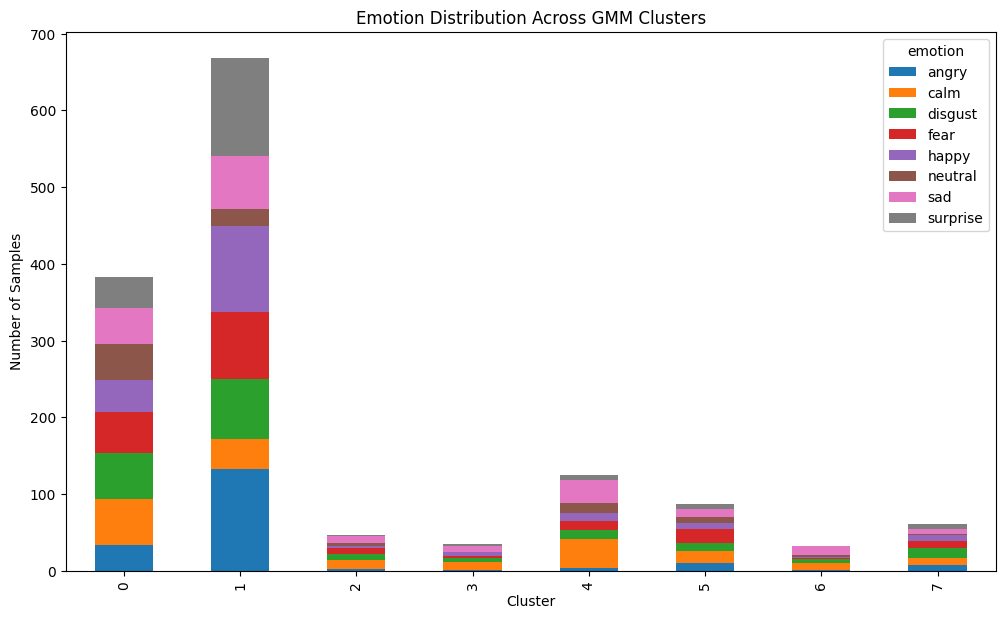

In [8]:
cluster_emotions.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.title("Emotion Distribution Across GMM Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.savefig("../results/cluster_emotion_distribution.png", dpi=300)

plt.show()

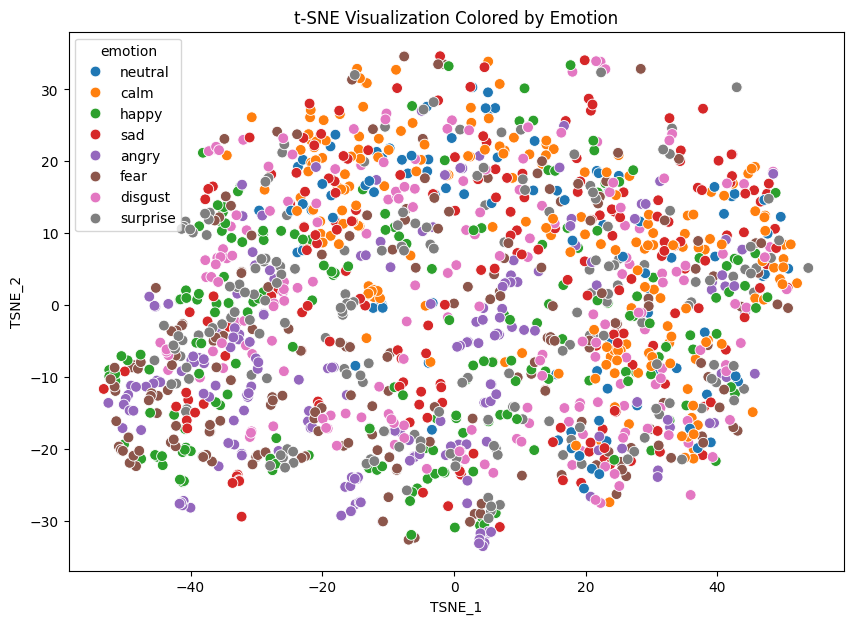

In [9]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df["TSNE_1"],
    y=df["TSNE_2"],
    hue=df["emotion"],
    palette="tab10",
    s=60
)

plt.title("t-SNE Visualization Colored by Emotion")
plt.savefig("../results/tsne_emotion_visualization.png", dpi=300)
plt.show()